In [ ]:

import warnings
warnings.filterwarnings("ignore")
import os
import sys
import json
import random

import requests
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import sklearn
import h5py
from numpy.linalg import norm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# Project path
sys.path.append("..")

from config import *
from utils.balanced_builders_hdf import *
from models.autoencoder_classifier import *
from final_pipline.similarity_latent import *
from final_pipline.latent_similarty_funcs import *
from final_pipline.external_testset import *

In [2]:
cs = build_balanced_cs_loaders_from_h5(
    h5_path=xrd_dataset,
    per_class_cs=105000,   
    val_split=0.1,
    test_split=0.1,
    seed=42,
    num_workers=4,
)
print(cs["counts"])
print(cs["sizes"])

{'triclinic': 105000, 'monoclinic': 105000, 'orthorhombic': 105000, 'tetragonal': 105000, 'trigonal': 105000, 'hexagonal': 105000, 'cubic': 105000}
{'train': 588000, 'val': 73500, 'test': 73500}


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate model EXACTLY the same way
model = DeepConvAutoencoderClassifier(
    input_length=cs["input_len"],
    latent_dim=64,
    cls_dim=128,
    num_classes=cs["num_classes"],
    use_projection_head=True
).to(device)

# Load state_dict safely
state_dict = torch.load(CS_Cls, map_location=device, weights_only=True)

model.load_state_dict(state_dict)

model.eval();

In [4]:
test_latents, test_labels, test_indices = extract_latent_vectors( model, cs, device,loader_name="test_loader")

In [5]:
os.makedirs(CS_LATENT, exist_ok=True)

test_latents_cs= os.path.join(CS_LATENT, "xrd_test_latents_cs.npz") 
np.savez_compressed(
   test_latents_cs,
    latents=test_latents.cpu().numpy() if hasattr(test_latents, "cpu") else test_latents,
    labels=test_labels,
    indices=test_indices,
    class_names=cs["class_names"])

In [4]:
sg_class_names = [
    1, 2, 8, 11, 12, 14, 15, 19,
    38, 61, 62, 63, 71, 123, 139,
    166, 187, 194, 216, 221, 225, 227
]

with h5py.File(external_test_ruff_dataset, "r") as f:
    x_test = f["xrd"][:]
    crystal_systems = f["crystalsystems"][:]
    xaxis = f["xaxis"][:]
    compositions = f["compositions"][:]
    labels = f["labels"][:]   # ← space group numbers

# Decode strings
crystal_systems = [
    cs.decode() if isinstance(cs, bytes) else cs
    for cs in crystal_systems
]

compositions = [
    c.decode() if isinstance(c, bytes) else c
    for c in compositions
]

# -----------------------------
# Filter by space group labels
# -----------------------------
mask = np.isin(labels, sg_class_names)

x_test = x_test[mask]
crystal_systems = np.array(crystal_systems)[mask]
compositions = np.array(compositions)[mask]
labels = labels[mask]

print("Remaining samples after SG filter:", len(x_test))

# -----------------------------
# Convert crystal systems → class index
# -----------------------------
class_names = cs["class_names"]

cls_to_idx = {name: i for i, name in enumerate(class_names)}

y_test = np.array([cls_to_idx[c] for c in crystal_systems])

# -----------------------------
# Dataset + loader
# -----------------------------
test_dataset = XRDDataset(x_test, y_test)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False)

Remaining samples after SG filter: 750


In [5]:
ruff_latents, ruff_labels, ruff_indices = extract_latent_vectors_from_loader(
    model,
    test_loader,
    device)

In [6]:
ruff_external_latents= os.path.join(CS_LATENT, "ruff_external_latents.npz") 
np.savez_compressed(
    ruff_external_latents,
    latents=ruff_latents,
    labels=ruff_labels,
    indices=ruff_indices,
    class_names=class_names
)


Internal test samples: 73500
RUFF samples: 750
Sampled internal points: 50000

Farthest RUFF sample from internal distribution:
RUFF index: 260
Distance: 153.17932


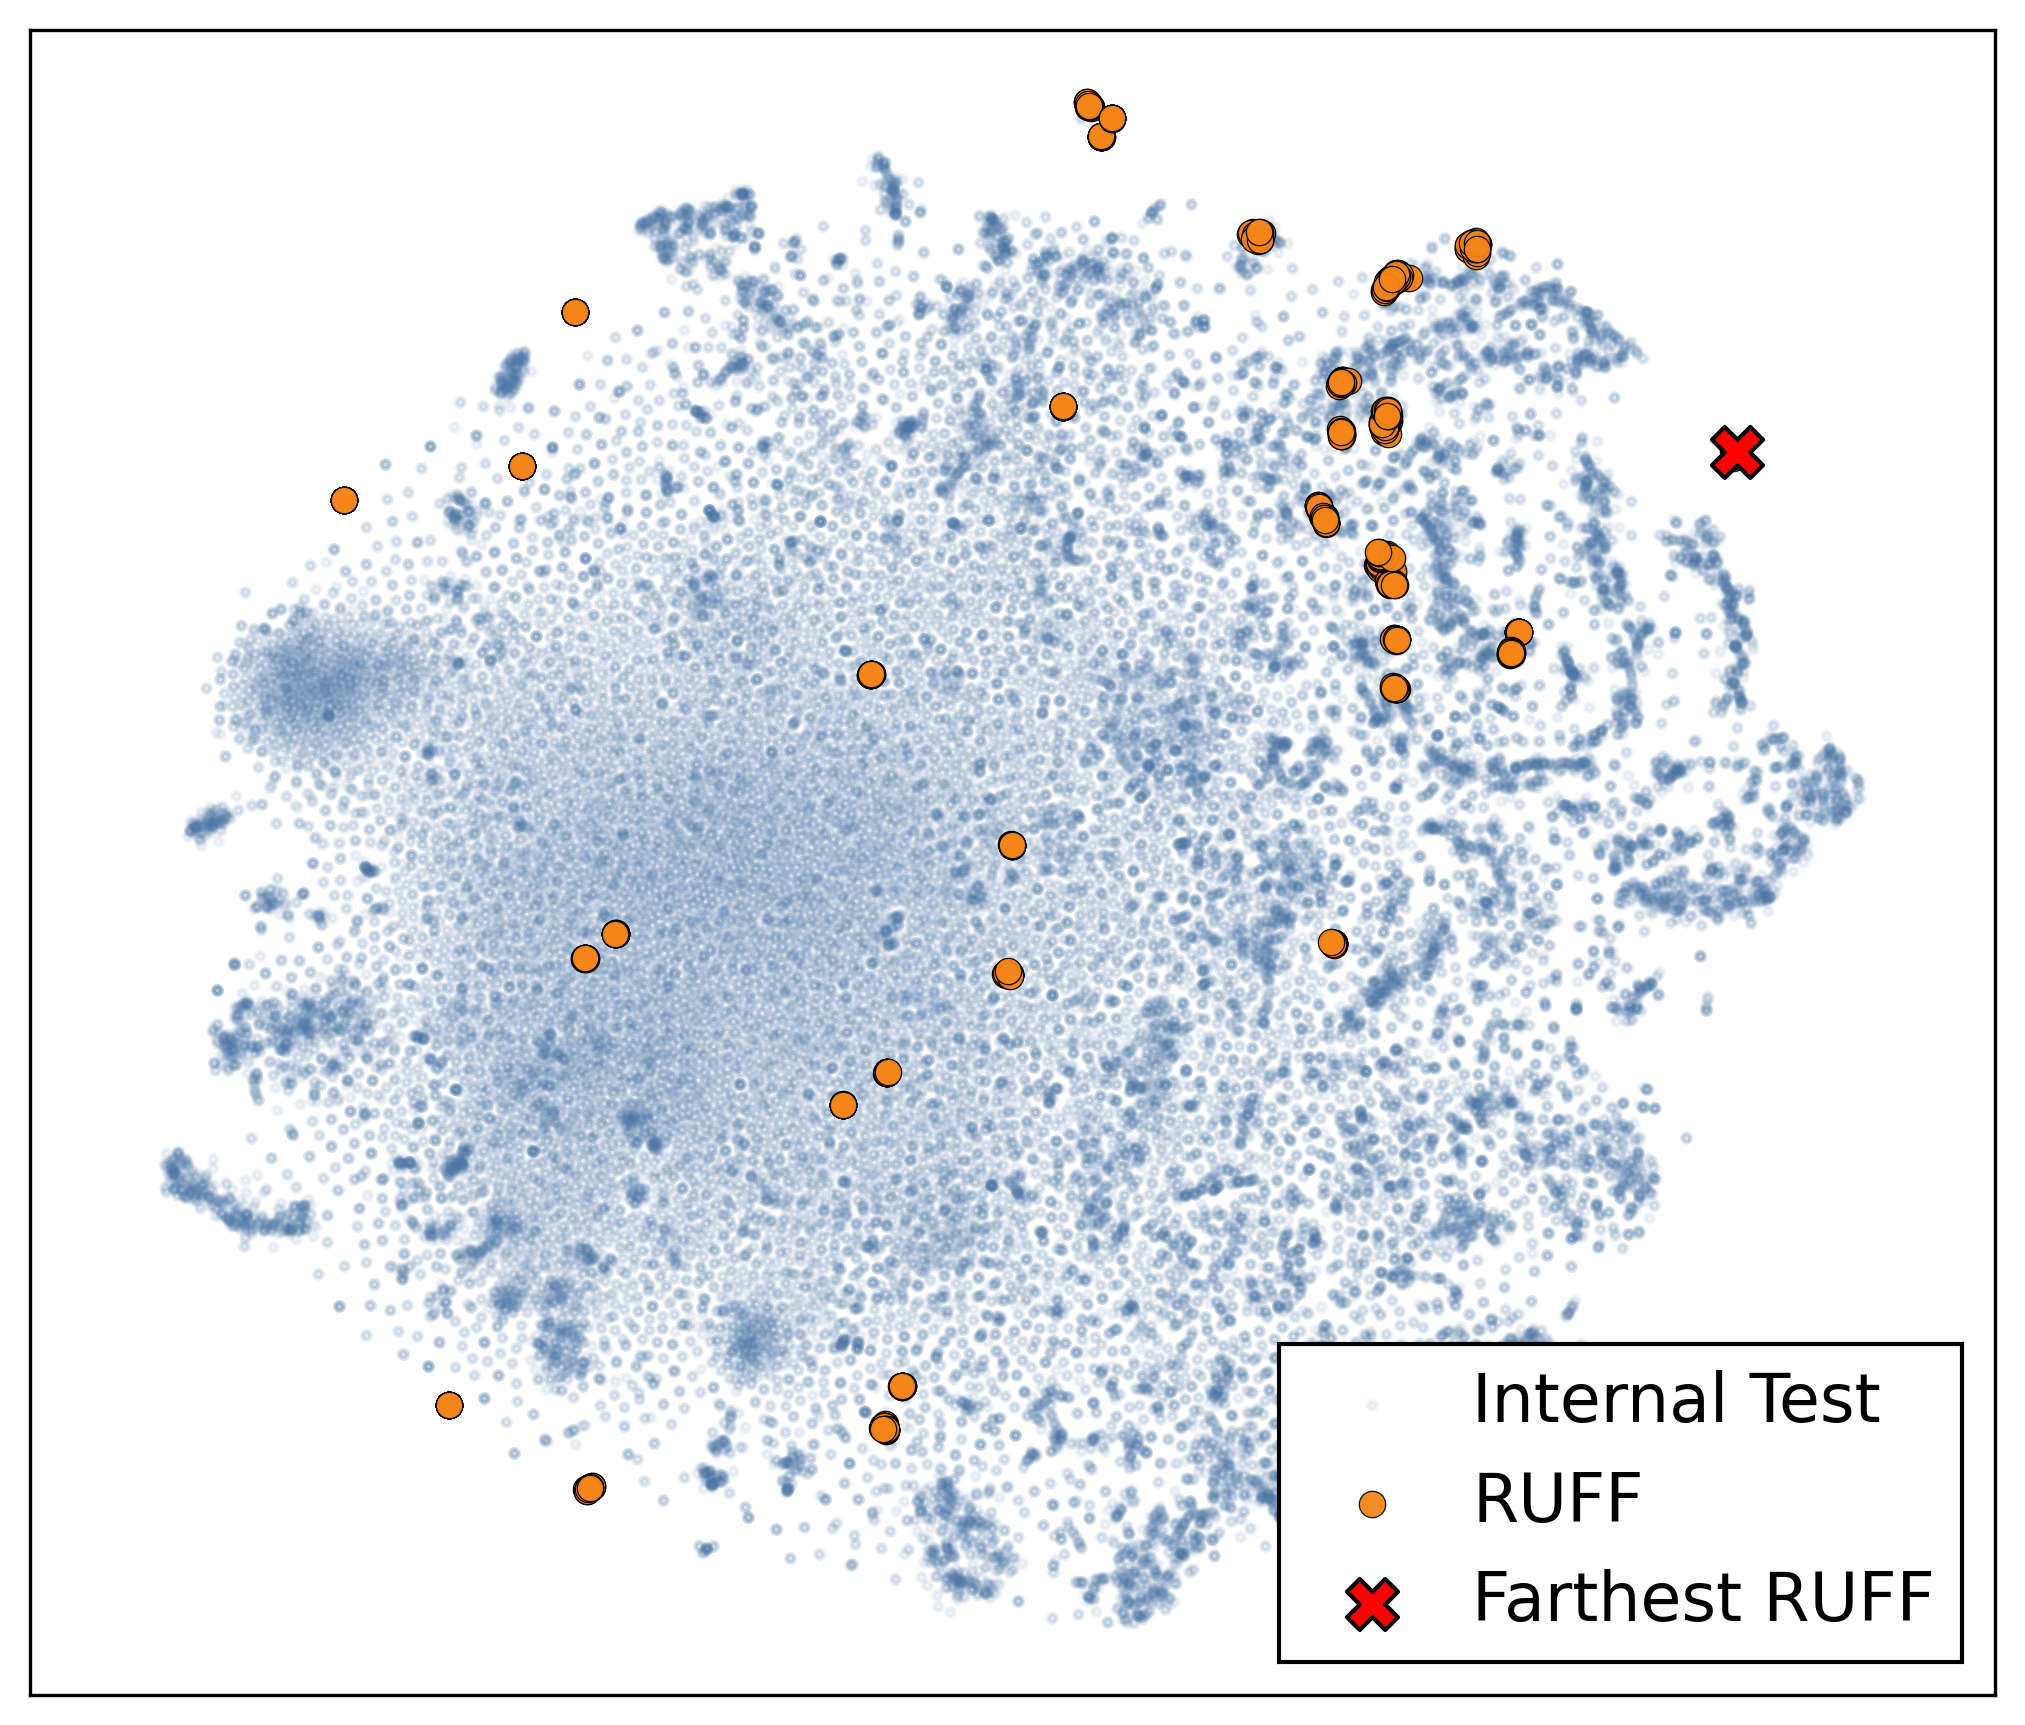

In [8]:
# -----------------------------
# Reproducibility
# -----------------------------
SEED = 50
np.random.seed(SEED)
random.seed(SEED)

# -----------------------------
# Plot style
# -----------------------------
plt.rcParams.update({
    "font.size": 15,
    "legend.fontsize": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.titlesize": 18,
    "legend.frameon": True
})
# -----------------------------
# Load latent datasets
# -----------------------------
test_latents_cs = os.path.join(CS_LATENT, "xrd_test_latents_cs.npz")
ruff_external_latents = os.path.join(CS_LATENT, "ruff_external_latents.npz")

cs_test = np.load(test_latents_cs, allow_pickle=True)
ruff = np.load(ruff_external_latents, allow_pickle=True)

lat_cs = cs_test["latents"]
lat_ruff = ruff["latents"]

print("Internal test samples:", len(lat_cs))
print("RUFF samples:", len(lat_ruff))

# -----------------------------
# Sample internal dataset
# -----------------------------
rng = np.random.default_rng(SEED)

n_sample = min(50000, len(lat_cs))
idx_cs = rng.choice(len(lat_cs), n_sample, replace=False)

lat_cs_small = lat_cs[idx_cs]

print("Sampled internal points:", len(lat_cs_small))

# -----------------------------
# Combine datasets
# -----------------------------
X = np.vstack([lat_cs_small, lat_ruff])

dataset_labels = (
    ["Internal Test"] * len(lat_cs_small) +
    ["RUFF"] * len(lat_ruff)
)

dataset_labels = np.array(dataset_labels)

# -----------------------------
# Standardization
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# PCA before t-SNE
# -----------------------------
pca_components = 48

if X_scaled.shape[1] > pca_components:
    pca = PCA(n_components=pca_components, random_state=SEED)
    X_scaled = pca.fit_transform(X_scaled)

# -----------------------------
# Run t-SNE
# -----------------------------
tsne = TSNE(
    n_components=2,
    perplexity=40,
    init="pca",
    learning_rate="auto",
    max_iter=1500,
    random_state=SEED
)

coords = tsne.fit_transform(X_scaled)

# -----------------------------
# Compute internal center
# -----------------------------
n_cs = len(lat_cs_small)

internal_coords = coords[:n_cs]
ruff_coords = coords[n_cs:]

internal_center = np.mean(internal_coords, axis=0)

# distance of RUFF points from internal distribution
ruff_distances = np.linalg.norm(ruff_coords - internal_center, axis=1)

# farthest RUFF sample
farthest_ruff_idx = np.argmax(ruff_distances)

print("\nFarthest RUFF sample from internal distribution:")
print("RUFF index:", farthest_ruff_idx)
print("Distance:", ruff_distances[farthest_ruff_idx])

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7, 6), dpi=300)

# Internal points
plt.scatter(
    internal_coords[:, 0],
    internal_coords[:, 1],
    s=4,
    alpha=0.08,
    color="#4C78A8",
    label="Internal Test",
    rasterized=True
)

# RUFF points
plt.scatter(
    ruff_coords[:, 0],
    ruff_coords[:, 1],
    s=40,
    color="#F58518",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.95,
    label="RUFF",
    zorder=5
)

# Highlight farthest RUFF
x_far = ruff_coords[farthest_ruff_idx, 0]
y_far = ruff_coords[farthest_ruff_idx, 1]

plt.scatter(
    x_far,
    y_far,
    s=150,
    marker="X",
    color="red",
    edgecolor="black",
    linewidth=1,
    zorder=10,
    label="Farthest RUFF"
)

plt.xticks([])
plt.yticks([])

plt.legend(
    loc="lower right",
    fontsize=16,
    frameon=True,
    fancybox=False,        
    framealpha=1.0,
    edgecolor="black",     
    borderpad=0.4,
    labelspacing=0.5,
    handletextpad=0.5
)

plt.axis("equal")
plt.tight_layout()

plt.savefig(
    "tsne_internal_external_ruff_farthest.pdf",
    bbox_inches="tight"
)

plt.show()

In [8]:
# -----------------------------
# Save reproducibility data
# -----------------------------
np.savez(
    "tsne_projection_results.npz",
    coords=coords,
    internal_coords=internal_coords,
    ruff_coords=ruff_coords,
    dataset_labels=dataset_labels,
    sampled_internal_indices=idx_cs,
    ruff_distances=ruff_distances,
    farthest_ruff_idx=farthest_ruff_idx,
    seed=SEED,
    perplexity=40,
    pca_components=pca_components,
    sklearn_version=sklearn.__version__
)

print("\nSaved reproducibility data → tsne_projection_results.npz")



Saved reproducibility data → tsne_projection_results.npz
